# Lending Club Dataset from 2007 to 2018

In [12]:
import os
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import polars as pl
pl.Config.set_tbl_rows(20)  # show up to 20 rows
import polars.selectors as cs
import seaborn as sns
sns.set_style("darkgrid")  # darkgrid
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

In [13]:
# Never use CSV again
accepted_df = pl.read_parquet(
    "/content/accepted_2007_to_2018Q4.parquet"
)
accepted_df.head()

ComputeError: parquet: File out of specification: The file must end with PAR1

This error occurred with the following context stack:
	[1] 'parquet scan'
	[2] 'sink'


In [ ]:
type_summary = (
    pl.DataFrame({
        "column": accepted_df.columns,
        "dtype":  [str(accepted_df[c].dtype) for c in accepted_df.columns],
        "nulls":  [accepted_df[c].is_null().sum() for c in accepted_df.columns],
        "null_pct": [round(accepted_df[c].is_null().sum() / len(accepted_df) * 100, 2) for c in accepted_df.columns],
    })
    .sort("dtype")
)

print(f"Dataset shape: f{len(accepted_df), len(accepted_df.columns)}")
print("\n----- Null Values Distribution -----")
print(type_summary)
print()
print("\n----- Datatype Counts -----")
print(
    type_summary
    .group_by("dtype")
    .agg(pl.count().alias("n_cols"))
    .sort("n_cols", descending=True)
)


In [ ]:
accepted_df

# EDA

In [14]:
# Null in issue_d -> null in all columns
print(accepted_df.filter(accepted_df["issue_d"].is_null()))

# Remove rows with missing values in issue_d
accepted_df = accepted_df.drop_nulls(subset=["issue_d"])
print("Remove null in column issue_d done!")

NameError: name 'accepted_df' is not defined

In [ ]:
# Polar String display
pl.Config.set_fmt_str_lengths(1000)

# Loan Status Distribution
print(f'Total Rows    : {accepted_df.shape[0]:,}')
print(f'Total Columns : {accepted_df.shape[1]}')
issue_d_parsed = pd.to_datetime(accepted_df['issue_d'], format='%b-%Y', errors='coerce')
print(f'Date Range    : {issue_d_parsed.min().strftime("%b-%Y")} → {issue_d_parsed.max().strftime("%b-%Y")}')

print('\n----- Loan Status Distribution -----')
print(accepted_df['loan_status'].value_counts().sort("count", descending=True))

In [ ]:
accepted_df['loan_status'].value_counts()

## Set up

In [ ]:
# Select only CHARGED OFF and FULLY PAID status
accepted_df = accepted_df.filter(
    pl.col("loan_status").is_in(["Fully Paid", "Charged Off"])
)

# Binary target: 1 = Charged Off (default), 0 = Fully Paid
accepted_df = accepted_df.with_columns(
    (pl.col("loan_status") == "Charged Off")
    .cast(pl.Int8)
    .alias("target")
)

# Overall default rate
default_rate = accepted_df['target'].mean() * 100
print(f"Overall Default Rate: {default_rate:.2f}%")

In [15]:
palette = {'Fully Paid': '#2ecc71', 'Charged Off': '#e74c3c'}

# Convert to pandas
plot_df = accepted_df.select(['loan_amnt', 'int_rate', 'grade', 'target']).to_pandas()
plot_df['label'] = plot_df['target'].map({0: 'Fully Paid', 1: 'Charged Off'})

# Grade default rate, converted to Pandas
grade_default = (
    accepted_df
    .group_by('grade')
    .agg(pl.col('target').mean().alias('default_rate'))
    .sort('grade')
    .to_pandas()
)

NameError: name 'accepted_df' is not defined

In [ ]:
# Loan amount histogram and boxplot
fig1, ax1 = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(
    data=plot_df, x='loan_amnt',
    bins=50, alpha=0.6, ax=ax1[0]
)
ax1[0].set_title('Loan Amount', fontweight='bold')
ax1[0].set_xlabel('Loan Amount ($)')
ax1[0].set_ylabel('Count')

sns.boxplot(
    data=plot_df, x='loan_amnt', y='label',
    palette=palette, ax=ax1[1], legend=False
)
ax1[1].set_title('Loan Amount by Loan Status', fontweight='bold')
ax1[1].set_xlabel('Loan Amount ($)')

plt.tight_layout()
plt.savefig('loan_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Interest rate histogram and boxplot
fig2, ax2 = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(
    data=plot_df, x='int_rate',
    bins=50, alpha=0.6, ax=ax2[0]
)
ax2[0].set_title('Interest Rate', fontweight='bold')
ax2[0].set_xlabel('Interest Rate (%)')
ax2[0].set_ylabel('Count')

sns.boxplot(
    data=plot_df, x='int_rate', y='label',
    palette=palette, ax=ax2[1], legend=False,
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
ax2[1].set_title('Interest Rate by Loan Status', fontweight='bold')
ax2[1].set_xlabel('Interest Rate (%)')

plt.tight_layout()
plt.savefig('interest_rate_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'grade_default' is not defined

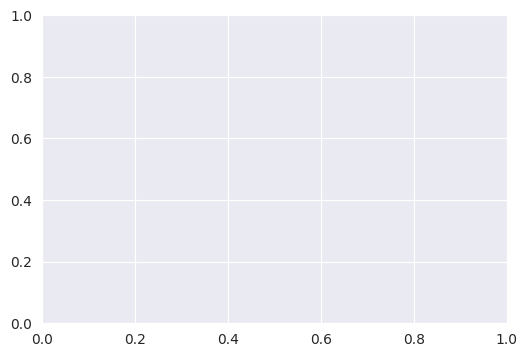

In [16]:
# Default Rate by Loan Grade
fig3, ax = plt.subplots(figsize=(6, 4))

sns.barplot(
    data=grade_default, x='grade', y='default_rate',
    palette='viridis', ax=ax
)
ax.set_title('Default Rate by Loan Grade', fontweight='bold')
ax.set_xlabel('Grade')
ax.set_ylabel('Default Rate')

for bar, (_, row) in zip(ax.patches, grade_default.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{row['default_rate']*100:.1f}%",
        ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.savefig('default_rate_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Calculate yearly numbers of loan and default statuses
yearly = (
    accepted_df
    .with_columns(
        pl.col("issue_d")
          .str.to_date(format="%b-%Y")
          .dt.year()
          .alias("issue_year")
    )
    .group_by("issue_year")
    .agg([
        pl.col("target").count().alias("total_loans"),
        pl.col("target").sum().alias("defaults")
    ])
    .with_columns(
        (pl.col("defaults") / pl.col("total_loans") * 100).alias("default_rate")
    )
    .sort("issue_year")
    .to_pandas()
)


# Convert year to string so bars spread across x-axis
yearly["issue_year"] = yearly["issue_year"].astype(str)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

# Plot: total loans on ax1
sns.barplot(
    data=yearly,
    x="issue_year",
    y="total_loans",
    alpha=0.4,
    color="#3498db",
    label="Total Loans",
    ax=ax1
)

# Plot: default rate on ax2
sns.lineplot(
    data=yearly,
    x="issue_year",
    y="default_rate",
    color="red",
    linewidth=2.5,
    marker="o",
    markersize=7,
    label="Default Rate %",
    ax=ax2
)

# Labels
ax1.set_xlabel("Issue Year", fontsize=12)
ax1.set_ylabel("Total Loans", fontsize=12, color="#3498db")
ax2.set_ylabel("Default Rate (%)", fontsize=12, color="red")

# Fix 2: remove ax2's auto legend before merging
ax2.get_legend().remove()

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Yearly Loan Volume & Default Rate Trend (2007–2018)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("yearly_trend.png", dpi=150, bbox_inches="tight")
plt.show()

# Feature Selection

In [ ]:
def feat_corr(df: pl.DataFrame, features: list) -> None:
    """
    Computes and plots a correlation heatmap for all numeric features.

    Args:
        df       : Polars DataFrame
        features : list of feature column names
    """

    # Select only numeric columns
    numeric_df = df.select(features).select(cs.numeric()).to_pandas()
    non_numeric = [c for c in available if c not in numeric_df.columns]

    print(f"  Numeric features   : {len(numeric_df.columns)}")
    print(f"  Non-numeric features)  : {non_numeric}")

    # Compute correlation matrix
    corr_matrix = numeric_df.corr()

    # Plot
    n = len(corr_matrix)
    fig, ax = plt.subplots(figsize=(n * 0.7 + 2, n * 0.6 + 2))

    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # upper triangle mask

    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 7},
        cmap="RdBu_r",
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.4,
        linecolor="white",
        square=True,
        cbar_kws={"shrink": 0.6, "label": "Pearson r"},
        ax=ax
    )

    ax.set_title("Feature Correlation Matrix (numeric only)",
                 fontsize=14, fontweight="bold", pad=15)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

    plt.tight_layout()
    plt.savefig("correlation_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Top 10 correlated pairs (excluding self-correlation)
    corr_pairs = (
        corr_matrix
        .unstack()
        .reset_index()
        .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlation"})
        .query("feature_1 != feature_2")                        # drop self
        .assign(abs_corr=lambda x: x["correlation"].abs())
        .drop_duplicates(subset=["abs_corr"])                   # drop mirror pairs
        .sort_values("abs_corr", ascending=False)
        .head(10)
    )

    print("\n  Top 10 most correlated pairs:")
    print(corr_pairs[["feature_1", "feature_2", "correlation"]].to_string(index=False))

In [ ]:
# Polars missing value analysis
missing_df = (
    pl.DataFrame({
        "column": accepted_df.columns,
        "null_count": [accepted_df[col].is_null().sum() for col in accepted_df.columns]
    })
    .with_columns(
        (pl.col("null_count") / len(accepted_df) * 100).alias("null_pct")
    )
    .filter(pl.col("null_pct") > 0)
    .sort("null_pct", descending=True)
)

# Summary statistics
over_50 = missing_df.filter(pl.col("null_pct") >  50)
between_20 = missing_df.filter(
                (pl.col("null_pct") >  20) &
                (pl.col("null_pct") <= 50)
             )

print(f"Number of features with > 50% missing: {over_50.height}")
print(f"Features with 20–50% missing: {between_20.height}")
print(f"Selected columns which is < 20% missing values:")
print(accepted_df.select([col for col in accepted_df.columns
                          if (col not in over_50["column"].to_list())
                          & (col not in between_20["column"].to_list())]).columns)

In [ ]:
missing_df

In [ ]:
FEATURES = [
    # Loan info
    'loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment',
    'grade', 'sub_grade', 'purpose',
    # Borrower financials
    'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    # Employment
    'emp_length', 'home_ownership',
    # Credit history
    'earliest_cr_line', 'fico_range_low', 'fico_range_high',
    'last_pymnt_amnt', 'tot_cur_bal', 'total_rev_hi_lim',
    # Risk
    'verification_status', 'pub_rec_bankruptcies', 'tax_liens',
    'acc_now_delinq', 'mort_acc', 'bc_util', 'percent_bc_gt_75',
    'num_rev_accts', 'num_tl_90g_dpd_24m',
    # Target
    'target'
]

# Filter to only existing columns (safety check)
available = [col for col in FEATURES if col in accepted_df.columns]
df = accepted_df.select(available)
print(f"Selected {len(available) - 1} features + target")
print(f"   Shape: {df.shape}")

# Columns not in dataset
missing_cols = [col for col in FEATURES if col not in accepted_df.columns]
if missing_cols:
    print(f" Warning — not found in df: {missing_cols}")

# Feature correlation
feat_corr(df, FEATURES)

In [ ]:
FEATURES_FINAL = [
    # Loan info
    'loan_amnt', 'term', 'int_rate',
    'grade', 'sub_grade', 'purpose',
    # Borrower financials
    'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
    # Employment
    'emp_length', 'home_ownership',
    # Credit history
    'earliest_cr_line', 'fico_score_avg',
    'last_pymnt_amnt', 'tot_cur_bal',
    # Risk
    'verification_status', 'pub_rec_bankruptcies', 'tax_liens',
    'acc_now_delinq', 'mort_acc', 'bc_util', 'percent_bc_gt_75',
    'num_rev_accts', 'num_tl_90g_dpd_24m',
    # Target
    'target'
]

In [ ]:
accepted_df = accepted_df.with_columns(
    (0.5 * pl.col('fico_range_low') + 0.5 * pl.col('fico_range_high')).alias("fico_score_avg")
)
clean_df = accepted_df.select(FEATURES_FINAL)
print(df.schema)           # dtypes
print(df.shape)            # (rows, cols)
print(df.null_count())

#  Separate features and target
X = df.drop("target")
y = df.select("target")
print(f"Final feature matrix : {X.shape}")
print(f" Target shape   : {y.shape}")
print(f" Default rate   : {y['target'].mean()*100:.2f}%")

# Pre-processing

## emp_length
emp_length: Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years.
$\rightarrow$ Replace $(<1, 0)$, $(10+, 10)$, and remove null rows

In [ ]:
print(clean_df["emp_length"].value_counts().sort("count", descending=True))

In [ ]:
clean_df = clean_df.with_columns(
    pl.col("emp_length")
    .str.replace("10\\+ years", "10 years")
    .str.replace("< 1 year", "0 years")
    .str.extract(r"(\d+)")
    .cast(pl.Int8)
    .alias("emp_length")
)

# Remove null values
clean_df = clean_df.drop_nulls(subset=["emp_length"])

print(clean_df["emp_length"].value_counts().sort("emp_length"))

In [ ]:
# Compute charge off rate by emp_length
emp_default = (
    clean_df
    .group_by("emp_length")
    .agg([
        pl.col("target").sum().alias("charged_off"),
        pl.len().alias("total")
    ])
    .with_columns(
        (pl.col("charged_off") / pl.col("total") * 100).alias("chargeoff_rate")
    )
    .sort("emp_length")
    .to_pandas()
)

plot_emp = clean_df.select(["emp_length", "target"]).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: count plot
sns.countplot(
    data=plot_emp,
    x="emp_length",
    ax=axes[0]
)
axes[0].set_title("Employment Length", fontweight="bold")
axes[0].set_xlabel("Employment Length (years)")
axes[0].set_ylabel("Count")

# Right: charge off rate
sns.barplot(
    data=emp_default,
    x="emp_length",
    y="chargeoff_rate",
    ax=axes[1]
)
axes[1].set_title("Charge Off Rate by Employment Length", fontweight="bold")
axes[1].set_xlabel("Employment Length (years)")
axes[1].set_ylabel("Charge Off Rate (%)")

## home_ownership
home_ownership: The home ownership status provided by the borrower.

Values: RENT, OWN, MORTGAGE, OTHER

In [ ]:
# Drop nulls and replace none/any to other
clean_df = (clean_df.drop_nulls(subset=["home_ownership"])
                  .with_columns(pl.col("home_ownership").replace({"NONE": "OTHER", "ANY": "OTHER"})))

print(clean_df["home_ownership"].value_counts().sort("count", descending=True))

# Before visualization
home_default = (
    clean_df
    .group_by("home_ownership")
    .agg([
        pl.col("target").sum().alias("charged_off"),
        pl.len().alias("total")
    ])
    .with_columns(
        (pl.col("charged_off") / pl.col("total") * 100).alias("chargeoff_rate")
    )
    .sort("home_ownership")
    .to_pandas()
)

In [ ]:
plot_home = clean_df.select(["home_ownership", "target"]).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(data=plot_home, x="home_ownership", ax=axes[0])
axes[0].set_title("Home Ownership", fontweight="bold")
axes[0].set_xlabel("Home Ownership")
axes[0].set_ylabel("Count")

sns.barplot(data=home_default, x="home_ownership", y="chargeoff_rate", ax=axes[1])
axes[1].set_title("Charge Off Rate by Home Ownership", fontweight="bold")
axes[1].set_xlabel("Home Ownership")
axes[1].set_ylabel("Charge Off Rate (%)")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig("home_ownership_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## verification_status

verification_status: Indicates if income was verified by LendingClub.

Values: Verified, Source Verified, Not Verified

In [ ]:
clean_df = clean_df.drop_nulls(subset=["verification_status"])
print(clean_df["verification_status"].value_counts().sort("count", descending=True))

vfi_default = (
    clean_df
    .group_by("verification_status")
    .agg([
        pl.col("target").sum().alias("charged_off"),
        pl.len().alias("total")
    ])
    .with_columns(
        (pl.col("charged_off") / pl.col("total") * 100).alias("chargeoff_rate")
    )
    .sort("verification_status")
    .to_pandas()
)

plot_vfi = clean_df.select(["verification_status", "target"]).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(data=plot_vfi, x="verification_status", ax=axes[0])
axes[0].set_title("Verification Status", fontweight="bold")
axes[0].set_xlabel("Verification Status")
axes[0].set_ylabel("Count")

sns.barplot(data=vfi_default, x="verification_status", y="chargeoff_rate", ax=axes[1])
axes[1].set_title("Charge Off Rate by Verification Status", fontweight="bold")
axes[1].set_xlabel("Verification Status")
axes[1].set_ylabel("Charge Off Rate (%)")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig("verification_status_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## pub_rec_bankcruptcies

In [ ]:
clean_df = clean_df.drop_nulls(subset=["pub_rec_bankruptcies"])

print(clean_df["pub_rec_bankruptcies"].value_counts().sort("count", descending=True))

bktc_default = (
    clean_df
    .group_by("pub_rec_bankruptcies")
    .agg([
        pl.col("target").sum().alias("charged_off"),
        pl.len().alias("total")
    ])
    .with_columns(
        (pl.col("charged_off") / pl.col("total") * 100).alias("chargeoff_rate")
    )
    .sort("chargeoff_rate", descending=True)
    .to_pandas()
)

In [ ]:
plot_bktc = clean_df.select(["pub_rec_bankruptcies", "target"]).to_pandas()
bktc_order = sorted(bktc_default["pub_rec_bankruptcies"].tolist())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=plot_bktc, x="pub_rec_bankruptcies", order=bktc_order, ax=axes[0])
axes[0].set_title("Public Record Bankruptcies", fontweight="bold")
axes[0].set_xlabel("Number recorded")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=bktc_default, x="pub_rec_bankruptcies", y="chargeoff_rate",
            order=bktc_order, ax=axes[1])
axes[1].set_title("Charge Off Rate by Public Record Bankruptcies", fontweight="bold")
axes[1].set_xlabel("Number recorded")
axes[1].set_ylabel("Charge Off Rate (%)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("purpose_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## purpose
purpose: A category provided by the borrower for the loan request.

Values: debt_consolidation, credit_card, home_improvement, etc.

In [ ]:
clean_df = clean_df.drop_nulls(subset=["purpose"])

print(clean_df["purpose"].value_counts().sort("count", descending=True))

purpose_default = (
    clean_df
    .group_by("purpose")
    .agg([
        pl.col("target").sum().alias("charged_off"),
        pl.len().alias("total")
    ])
    .with_columns(
        (pl.col("charged_off") / pl.col("total") * 100).alias("chargeoff_rate")
    )
    .sort("chargeoff_rate", descending=True)
    .to_pandas()
)

In [ ]:
plot_purpose = clean_df.select(["purpose", "target"]).to_pandas()
purpose_order = sorted(purpose_default["purpose"].tolist())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=plot_purpose, x="purpose", order=purpose_order, ax=axes[0])
axes[0].set_title("Loan Purpose", fontweight="bold")
axes[0].set_xlabel("Purpose")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=purpose_default, x="purpose", y="chargeoff_rate",
            order=purpose_order, ax=axes[1])
axes[1].set_title("Charge Off Rate by Loan Purpose", fontweight="bold")
axes[1].set_xlabel("Purpose")
axes[1].set_ylabel("Charge Off Rate (%)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("purpose_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## annual_inc

annual_inc: The self-reported annual income provided by the borrower.

In [ ]:
clean_df = clean_df.drop_nulls(subset=["annual_inc"])

print(clean_df["annual_inc"].describe())

# Bin into brackets
clean_df = clean_df.with_columns(
    pl.when(pl.col("annual_inc") < 30000).then(pl.lit("< 30k"))
    .when(pl.col("annual_inc") < 60000).then(pl.lit("30k–60k"))
    .when(pl.col("annual_inc") < 90000).then(pl.lit("60k–90k"))
    .when(pl.col("annual_inc") < 120000).then(pl.lit("90k–120k"))
    .otherwise(pl.lit("120k+"))
    .alias("income_bracket")
)

bracket_order = ["< 30k", "30k–60k", "60k–90k", "90k–120k", "120k+"]

inc_default = (
    clean_df
    .group_by("income_bracket")
    .agg([
        pl.col("target").sum().alias("charged_off"),
        pl.len().alias("total")
    ])
    .with_columns(
        (pl.col("charged_off") / pl.col("total") * 100).alias("chargeoff_rate")
    )
    .to_pandas()
)
inc_default["income_bracket"] = pd.Categorical(inc_default["income_bracket"],
                                                categories=bracket_order, ordered=True)
inc_default = inc_default.sort_values("income_bracket")

plot_inc = clean_df.select(["income_bracket", "target"]).to_pandas()
plot_inc["income_bracket"] = pd.Categorical(plot_inc["income_bracket"],
                                             categories=bracket_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(data=plot_inc, x="income_bracket", order=bracket_order, ax=axes[0])
axes[0].set_title("Annual Income", fontweight="bold")
axes[0].set_xlabel("Income Bracket")
axes[0].set_ylabel("Count")

sns.barplot(data=inc_default, x="income_bracket", y="chargeoff_rate",
            order=bracket_order, ax=axes[1])
axes[1].set_title("Charge Off Rate by Annual Income", fontweight="bold")
axes[1].set_xlabel("Income Bracket")
axes[1].set_ylabel("Charge Off Rate (%)")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig("annual_inc_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## annual_inc × purpose
Examine how charge off rate varies across income brackets within each loan purpose

In [ ]:
combo = (
    clean_df
    .group_by(["income_bracket", "purpose"])
    .agg([
        pl.col("target").sum().alias("charged_off"),
        pl.len().alias("total")
    ])
    .with_columns(
        (pl.col("charged_off") / pl.col("total") * 100).alias("chargeoff_rate")
    )
    .to_pandas()
)

combo["income_bracket"] = pd.Categorical(combo["income_bracket"],
                                          categories=bracket_order, ordered=True)
combo = combo.sort_values(["purpose", "income_bracket"])

# charge off rate heatmap (income bracket vs purpose)
heatmap_df = combo.pivot(index="purpose", columns="income_bracket", values="chargeoff_rate")
heatmap_df = heatmap_df[bracket_order]  # enforce column order

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap="RdBu_r",
    linewidths=0.5,
    cbar_kws={"label": "Charge Off Rate (%)"}
)
plt.title("Charge Off Rate (%) by Income & Purpose", fontweight="bold")
plt.xlabel("Income Bracket")
plt.ylabel("Purpose")
plt.tight_layout()
plt.savefig("annual_inc_purpose_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## fico_score
fico_score_avg = (fico_score_low + fico_score_high) / 2

In [ ]:
fico_stats = clean_df.select(["target", "fico_score_avg"]).to_pandas()
fico_stats.groupby("target")["fico_score_avg"].describe()

In [ ]:
plot_df = clean_df.select(["loan_amnt", "emp_length", "dti", "grade"]).to_pandas()

## Debt-to-income_ratio

In [ ]:
dti_loan = clean_df.select(["target", "dti", "grade"]).to_pandas()
dti_loan.groupby("target")["dti"].describe()

In [ ]:
sns.boxplot(
    data=dti_loan,
    x="grade",
    y="dti",
    order=sorted(plot_df["grade"].dropna().unique()),
    palette="viridis",
)
plt.title("DTI by Loan Grade", fontweight="bold")
plt.xlabel("Loan Grade")
plt.ylabel("Debt-to-Income Ratio (DTI)")
plt.savefig("dti_boxplot.png", dpi=150, bbox_inches="tight")
plt.ylim(0, 100)

## open_acc
open_acc: The number of open credit lines in the borrower's credit file

In [ ]:
open_accounts = clean_df.select(["target", "open_acc"]).to_pandas()
open_accounts.groupby("target")["open_acc"].describe()

In [ ]:
plt.figure(figsize=(10,3), dpi=90)
sns.countplot(open_accounts['open_acc'], order=sorted(open_accounts['open_acc'].unique()))
plt.xticks(np.arange(0, 90, 5), np.arange(0, 90, 5))
plt.title('Number of Open Credit Lines')

## mort_acc
mort_acc: Number of mortgage accounts

**Insight: **Individuals who pay off their loans are more likely to have several mortgage accounts.

In [ ]:
mort_accounts = clean_df.select(["target", "mort_acc"]).to_pandas()
mort_accounts.groupby("target")["mort_acc"].describe()

Individuals who pay off their loans are more likely to have several mortgage accounts.

# Feature Engineering

In [ ]:
# # Feature engineering
# X_fe = X.with_columns([

#     # Credit history age (earliest_cr_line → years)
#     (pl.lit(2018) - pl.col("earliest_cr_line")
#         .str.to_date(format="%b-%Y", strict=False)
#         .dt.year()
#     ).alias("credit_age_years"),

#     # Monthly debt burden
#     (pl.col("installment") / (pl.col("annual_inc") / 12 + 1))
#         .alias("monthly_debt_burden"),

#     # Utilization to revolving balance ratio
#     (pl.col("revol_util") / (pl.col("revol_bal") + 1))
#         .alias("util_bal_ratio"),

#     # Loan amount to income
#     (pl.col("loan_amnt") / (pl.col("annual_inc") + 1))
#         .alias("loan_to_income"),

#     # Open accounts ratio
#     (pl.col("open_acc") / (pl.col("total_acc") + 1))
#         .alias("open_acc_ratio"),

#     # Interest rate flag
#     (pl.col("int_rate") > 20).cast(pl.Int8)
#         .alias("high_rate_flag"),

#     # Calculate fico_avg
#     ((pl.col("fico_range_low") + pl.col("fico_range_high")) / 2).alias("fico_avg"),

#     # FICO flag
#     (pl.col("fico_avg") < 660).cast(pl.Int8)
#         .alias("poor_fico_flag")

# ]).drop("earliest_cr_line")  # replaced by credit_age_years

# print(f"Feature engineering done")
# print(f"  New features : credit_age_years, mths_since_recent_inq,")
# print(f"                 monthly_debt_burden, util_bal_ratio,")
# print(f"                 loan_to_income, open_acc_ratio,")
# print(f"                 high_rate_flag, poor_fico_flag")
# print(f"  Total features: {X_fe.shape[1]}")

## Pre RL Model

In [ ]:
!nvidia-smi

In [ ]:
# !pip install cuml-cu12 --extra-index-url=https://pypi.nvidia.com

In [ ]:
import cudf
import cupy as cp

from cuml.cluster import KMeans as cuKMeans
from cuml.preprocessing import StandardScaler as cuStandardScaler
from cuml.preprocessing import LabelEncoder as cuLabelEncoder
from cuml.decomposition import PCA as cuPCA
from sklearn.metrics import silhouette_score

In [ ]:
# Input features for RL model
features = ['fico_score_avg', 'dti', 'annual_inc', 'emp_length', 'purpose']
# Select features from clean_df
state_df = clean_df.select(features).clone()
# Drop missing values from the selected features
state_df = state_df.drop_nulls()
# Convert to Pandas DataFrame to use sklearn
state_pd_df = state_df.to_pandas()

# Convert pandas → cuDF
gdf = cudf.from_pandas(state_pd_df)

# Encode categorical feature
le = cuLabelEncoder()
gdf['purpose'] = le.fit_transform(gdf['purpose'])

# Scale features (GPU)
scaler = cuStandardScaler()
X_gpu = scaler.fit_transform(gdf.astype('float32'))

# # Model
# inertia = []
# silhouette = []
# K_range = range(2, 7)

# for k in K_range:
#     kmeans = cuKMeans(
#         n_clusters=k,
#         init="k-means||",   # GPU equivalent of k-means++
#         random_state=42,
#         max_iter=300
#     )

#     labels_gpu = kmeans.fit_predict(X_gpu)

#     # inertia (GPU → CPU)
#     inertia.append(kmeans.inertia_)

#     # silhouette requires CPU → convert
#     labels_cpu = labels_gpu.to_numpy()
#     X_cpu = X_gpu.to_numpy()

#     silhouette.append(silhouette_score(X_cpu, labels_cpu))
#     print(k)

# # --- Plot Elbow ---
# plt.figure(figsize=(10,4))
# plt.subplot(1,2,1)
# plt.plot(K_range, inertia, marker='o')
# plt.title("Elbow Method")
# plt.xlabel("K")
# plt.ylabel("Inertia")

# # --- Plot Silhouette ---
# plt.subplot(1,2,2)
# plt.plot(K_range, silhouette, marker='o')
# plt.title("Silhouette Score")
# plt.xlabel("K")
# plt.ylabel("Score")

# plt.tight_layout()
# plt.show()

# # Choose optimal K that gets max silhouette
# optimal_k = K_range[np.argmax(silhouette)]
# print("Optimal K:", optimal_k)

In [ ]:
# # Input features for RL model
# features = ['fico_score_avg', 'dti', 'annual_inc', 'emp_length', 'purpose']
# # Select features from clean_df
# state_df = clean_df.select(features).clone()
# # Drop missing values from the selected features
# state_df = state_df.drop_nulls()
# # Convert to Pandas DataFrame to use sklearn
# state_pd_df = state_df.to_pandas()
# # Encode 'purpose' using LabelEncoder
# le = LabelEncoder()
# state_pd_df['purpose'] = le.fit_transform(state_pd_df['purpose'])
# # Scale numeric features
# scaler = StandardScaler()
# # Apply scaler to all columns of the Pandas DataFrame
# X = scaler.fit_transform(state_pd_df)

# # K-means clustering on 5 chosen features
# # inertia: distance to centroid, silhouette: within cluster and to other cluster
# inertia = []
# silhouette = []
# K_range = range(2, 7)

# for k in K_range:
#     kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=1)
#     labels = kmeans.fit_predict(X)

#     inertia.append(kmeans.inertia_)
#     silhouette.append(silhouette_score(X, labels))
#     print(k)

# # --- Plot Elbow ---
# plt.figure(figsize=(10,4))
# plt.subplot(1,2,1)
# plt.plot(K_range, inertia, marker='o')
# plt.title("Elbow Method")
# plt.xlabel("K")
# plt.ylabel("Inertia")

# # --- Plot Silhouette ---
# plt.subplot(1,2,2)
# plt.plot(K_range, silhouette, marker='o')
# plt.title("Silhouette Score")
# plt.xlabel("K")
# plt.ylabel("Score")

# plt.tight_layout()
# plt.show()

# # Choose optimal K that gets max silhouette
# optimal_k = K_range[np.argmax(silhouette)]
# print("Optimal K:", optimal_k)

In [ ]:
pca = cuPCA(n_components=2)
X_pca_gpu = pca.fit_transform(X_gpu)

state_df['pca1'] = X_pca[:,0]
state_df['pca2'] = X_pca[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='pca1', y='pca2',
    hue='cluster',
    palette='tab10',
    data=state_df,
    alpha=0.6
)
plt.title("PCA Visualization of Clusters")
plt.show()

# =========================
# 9. CENTROID ANALYSIS
# =========================

centroids_gpu = kmeans.cluster_centers_
centroids_cpu = cp.asnumpy(centroids_gpu)

# inverse scaling (CPU)
centroids = pd.DataFrame(
    scaler.inverse_transform(centroids_cpu),
    columns=features
)

print("\nCluster Centroids (Original Scale):\n", centroids)

# =========================
# 10. OPTIONAL: RL STATE COMPARISON
# =========================
# If you have RL 6-dim state (example: add extra feature)
# Example: df_rl = df.copy()
# df_rl['extra_feature'] = ...

# Then repeat clustering and compare using:
# - Adjusted Rand Index
# - centroid distance

from sklearn.metrics import adjusted_rand_score

# Example placeholder:
# ari = adjusted_rand_score(df['cluster'], df_rl['cluster'])
# print("Cluster overlap (ARI):", ari)